In [1]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.lib.distances import capped_distance
import matplotlib.pyplot as plt

In [24]:
PATH='complex_polySia_DP5'
u = mda.Universe(f'complexes/{PATH}/md_complex.gro', f'complexes/{PATH}/md_complex.xtc')

/home/courtade/miniforge3/envs/py3/lib/python3.13/site-packages/MDAnalysis/coordinates/XDR.py:253: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


In [25]:
# Create atom groups
protein = u.select_atoms("protein")
ligands = u.select_atoms("resname ROH or resname 8SA or resname 0SA")

In [26]:
cutoff = 3.5
interacting_residues = {}

# Pre-compute residue information for each protein atom
residue_mapping = np.array([(atom.residue.resname, atom.residue.resid) 
                           for atom in protein])

# Iterate through trajectory
for ts in u.trajectory:
    # Use capped_distance instead of distance_array - much faster for cutoff-based calculations
    pairs = capped_distance(protein.positions,
                          ligands.positions,
                          max_cutoff=cutoff,
                          box=u.dimensions,
                          return_distances=False)
    
    if len(pairs) > 0:
        # Get unique protein atoms that interact (first column of pairs array)
        interacting_atom_indices = np.unique(pairs[:, 0])
        
        # Get residue information for interacting atoms using pre-computed mapping
        frame_residues = set(tuple(x) for x in residue_mapping[interacting_atom_indices])
        
        interacting_residues[ts.frame] = sorted(list(frame_residues))
    else:
        interacting_residues[ts.frame] = []
    



In [27]:
interacting_residues

{0: [],
 1: [(np.str_('TRP'), np.str_('8'))],
 2: [(np.str_('ARG'), np.str_('34')),
  (np.str_('HIS'), np.str_('31')),
  (np.str_('LEU'), np.str_('28'))],
 3: [(np.str_('ARG'), np.str_('19')),
  (np.str_('ARG'), np.str_('34')),
  (np.str_('HIS'), np.str_('31')),
  (np.str_('HIS'), np.str_('32')),
  (np.str_('LEU'), np.str_('28')),
  (np.str_('LYS'), np.str_('6')),
  (np.str_('TRP'), np.str_('8'))],
 4: [(np.str_('ARG'), np.str_('19')),
  (np.str_('ARG'), np.str_('3')),
  (np.str_('ARG'), np.str_('34')),
  (np.str_('HIS'), np.str_('31')),
  (np.str_('LEU'), np.str_('28')),
  (np.str_('LYS'), np.str_('6')),
  (np.str_('TRP'), np.str_('8'))],
 5: [(np.str_('ARG'), np.str_('11')),
  (np.str_('ARG'), np.str_('34')),
  (np.str_('HIS'), np.str_('31')),
  (np.str_('LEU'), np.str_('28')),
  (np.str_('LYS'), np.str_('29')),
  (np.str_('TRP'), np.str_('8'))],
 6: [(np.str_('ARG'), np.str_('11')),
  (np.str_('ARG'), np.str_('3')),
  (np.str_('ARG'), np.str_('34')),
  (np.str_('GLY'), np.str_('30')

In [28]:
def analyze_interaction_frequency(interacting_residues):
    """
    Analyze how frequently each residue interacts with the ligands.
    
    Parameters:
    -----------
    interacting_residues : dict
        Output from find_interacting_residues()
        
    Returns:
    --------
    dict : Dictionary with residues as keys and interaction frequencies as values
    """
    # Count total frames
    n_frames = len(interacting_residues)
    
    # Count appearances of each residue
    residue_counts = {}
    for frame_residues in interacting_residues.values():
        for res in frame_residues:
            residue_counts[res] = residue_counts.get(res, 0) + 1
    
    # Convert to frequencies
    residue_frequencies = {res: count/n_frames 
                         for res, count in residue_counts.items()}
    
    return residue_frequencies


In [29]:
frequencies = analyze_interaction_frequency(interacting_residues)
interaction_freq = []
selection_string = 'select binding_site, resi '
threshold_freq = 0.85
# Print results
for resid in protein.residues.resids:
    this_freq = 0.0
    for res, freq in sorted(frequencies.items(), key=lambda x: int(x[0][1]), reverse=False):
        if resid == int(res[1]):
            this_freq = freq
            if this_freq > threshold_freq:
                selection_string += f'{res[1]}+'
            break        
    interaction_freq.append(this_freq)        
            
        #print(f"{res[0]}{res[1]}: {freq*100:.1f}% of frames")
print(f'Residues with freq > {threshold_freq}')
print(selection_string[:-1])

with open(f'freq_{PATH}.txt', 'w') as f:
    f.write(f'Residues with freq > {threshold_freq}\n')
    f.write(selection_string[:-1])
interaction_freq = np.array(interaction_freq)

Residues with freq > 0.85
select binding_site, resi 2+4+5+6+7+8+11+15+34+35+36


In [30]:
def find_interacting_residues(protein, ligand, cutoff=3.5):
    """
    Find protein residues that interact with any copy of a ligand.
    Returns both the contacts dictionary and a contact matrix for plotting.
    """
   
    # Get unique residue IDs for mapping
    unique_resids = sorted(set(protein.residues.resids))
    resid_to_idx = {resid: idx for idx, resid in enumerate(unique_resids)}
    
    # Initialize contact matrix (time points × residues)
    n_frames = len(u.trajectory)
    contact_matrix = np.zeros((n_frames, len(unique_resids)))
    
    # Iterate through trajectory
    for ts in u.trajectory:
        pairs = capped_distance(protein.positions,
                              ligands.positions,
                              max_cutoff=cutoff,
                              box=u.dimensions,
                              return_distances=False)
        
        if len(pairs) > 0:
            # Get residue IDs of interacting atoms
            interacting_resids = set(protein[idx].residue.resid for idx in np.unique(pairs[:, 0]))
            
            # Update contact matrix
            for resid in interacting_resids:
                contact_matrix[ts.frame, resid_to_idx[resid]] = 1
    
    return contact_matrix, unique_resids

def plot_contact_map(contact_matrix, resids, time_step=1, fig_size=(10, 6)):
    """
    Plot a contact map showing protein-ligand interactions over time.
    
    Parameters:
    -----------
    contact_matrix : numpy.ndarray
        Matrix of contacts (time points × residues)
    resids : list
        List of residue IDs corresponding to matrix columns
    time_step : float
        Time step between frames in nanoseconds
    fig_size : tuple
        Figure size in inches
    """
    # Calculate time array in microseconds




In [31]:
# Get contact matrix
contact_matrix, resids = find_interacting_residues(protein, ligands)



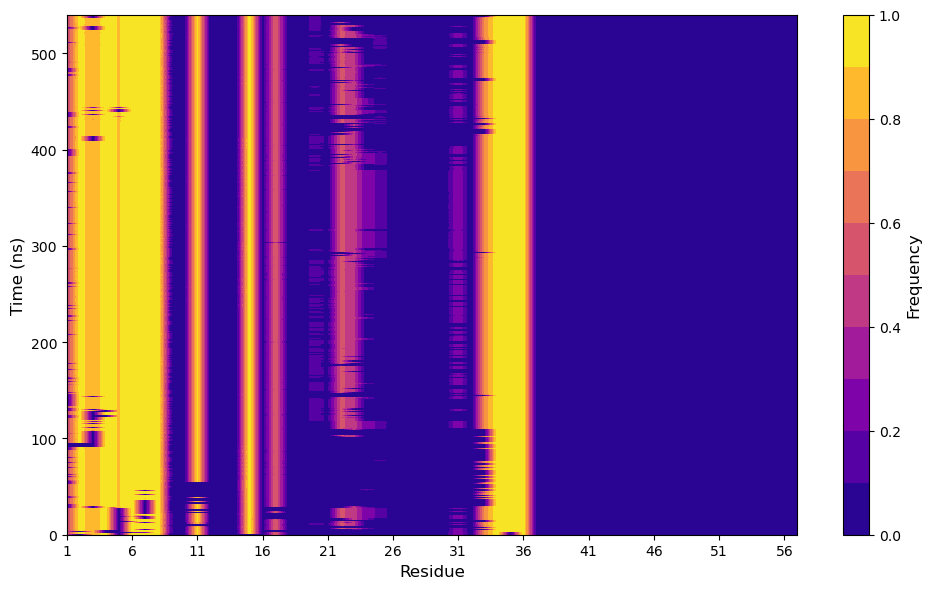

In [32]:
time_step = 100  # ps per frame
n_frames = contact_matrix.shape[0]
time = np.arange(n_frames) * time_step / 1000  # Convert to microseconds
res_numbers = np.arange(1, len(resids) + 1)

# Create figure
plt.figure(figsize=(10,6))

# Create contact map
plt.contourf(res_numbers, time, contact_matrix*interaction_freq, cmap='plasma',levels=np.arange(0, 1.1, 0.1)) 

# Customize plot
plt.xlabel('Residue', fontsize=12)
plt.ylabel('Time (ns)', fontsize=12)

# Set reasonable tick intervals for residue numbers
tick_interval = max(1, len(resids) // 10)  # Show ~10 ticks
plt.xticks(res_numbers[::tick_interval], resids[::tick_interval])

cbar = plt.colorbar()
cbar.set_label('Frequency', fontsize=12)

# Adjust layout
plt.tight_layout()
    
# Customize further if needed
plt.xlim(1, len(resids))
plt.ylim(0, (len(contact_matrix) * time_step) / 1000)  # Convert to µs

plt.savefig(f'contacts_{PATH}.png', dpi=300)

# Show plot
plt.show()
